In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
nav = pd.read_csv("../data/processed/02_nav_history_cleaned.csv")

scheme = pd.read_csv("../data/processed/07_scheme_performance_cleaned.csv")

investor = pd.read_csv("../data/processed/08_investor_transactions_cleaned.csv")

portfolio = pd.read_csv("../data/processed/09_portfolio_holdings_cleaned.csv")

In [3]:
print("NAV")
print(nav.columns)

print("\nSCHEME")
print(scheme.columns)

print("\nINVESTOR")
print(investor.columns)

print("\nPORTFOLIO")
print(portfolio.columns)


NAV
Index(['amfi_code', 'date', 'nav'], dtype='str')

SCHEME
Index(['amfi_code', 'scheme_name', 'fund_house', 'category', 'plan',
       'return_1yr_pct', 'return_3yr_pct', 'return_5yr_pct',
       'benchmark_3yr_pct', 'alpha', 'beta', 'sharpe_ratio', 'sortino_ratio',
       'std_dev_ann_pct', 'max_drawdown_pct', 'aum_crore', 'expense_ratio_pct',
       'morningstar_rating', 'risk_grade'],
      dtype='str')

INVESTOR
Index(['investor_id', 'transaction_date', 'amfi_code', 'transaction_type',
       'amount_inr', 'state', 'city', 'city_tier', 'age_group', 'gender',
       'annual_income_lakh', 'payment_mode', 'kyc_status'],
      dtype='str')

PORTFOLIO
Index(['amfi_code', 'stock_symbol', 'stock_name', 'sector', 'weight_pct',
       'market_value_cr', 'current_price_inr', 'portfolio_date'],
      dtype='str')


In [5]:
print("NAV:", nav.shape)
print("SCHEME:", scheme.shape)
print("INVESTOR:", investor.shape)
print("PORTFOLIO:", portfolio.shape)

NAV: (46000, 3)
SCHEME: (40, 19)
INVESTOR: (32778, 13)
PORTFOLIO: (322, 8)


In [6]:
print("SCHEME")
print(scheme.isnull().sum())

print("\nINVESTOR")
print(investor.isnull().sum())

print("\nPORTFOLIO")
print(portfolio.isnull().sum())

SCHEME
amfi_code             0
scheme_name           0
fund_house            0
category              0
plan                  0
return_1yr_pct        0
return_3yr_pct        0
return_5yr_pct        0
benchmark_3yr_pct     0
alpha                 0
beta                  0
sharpe_ratio          0
sortino_ratio         0
std_dev_ann_pct       0
max_drawdown_pct      0
aum_crore             0
expense_ratio_pct     0
morningstar_rating    0
risk_grade            0
dtype: int64

INVESTOR
investor_id           0
transaction_date      0
amfi_code             0
transaction_type      0
amount_inr            0
state                 0
city                  0
city_tier             0
age_group             0
gender                0
annual_income_lakh    0
payment_mode          0
kyc_status            0
dtype: int64

PORTFOLIO
amfi_code            0
stock_symbol         0
stock_name           0
sector               0
weight_pct           0
market_value_cr      0
current_price_inr    0
portfolio_date   

In [4]:
scheme.describe()
investor.describe()
portfolio.describe()

,amfi_code,weight_pct,market_value_cr,current_price_inr
count,322.000000,322.000000,322.000000,322.000000
mean,121210.434783,10.558975,1008.846646,4080.870528
std,14669.377920,6.060137,543.827535,2265.186353
min,100016.000000,0.990000,55.740000,246.780000
25%,118633.000000,6.015000,513.702500,2081.985000
50%,119552.000000,9.395000,1045.670000,4138.995000
75%,120842.750000,13.917500,1477.502500,5914.307500
max,149324.000000,38.180000,1999.500000,7942.960000


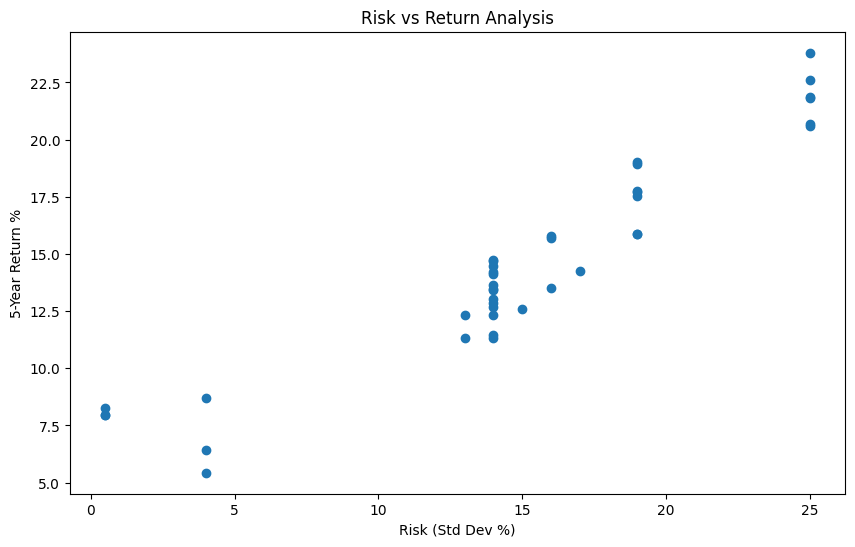

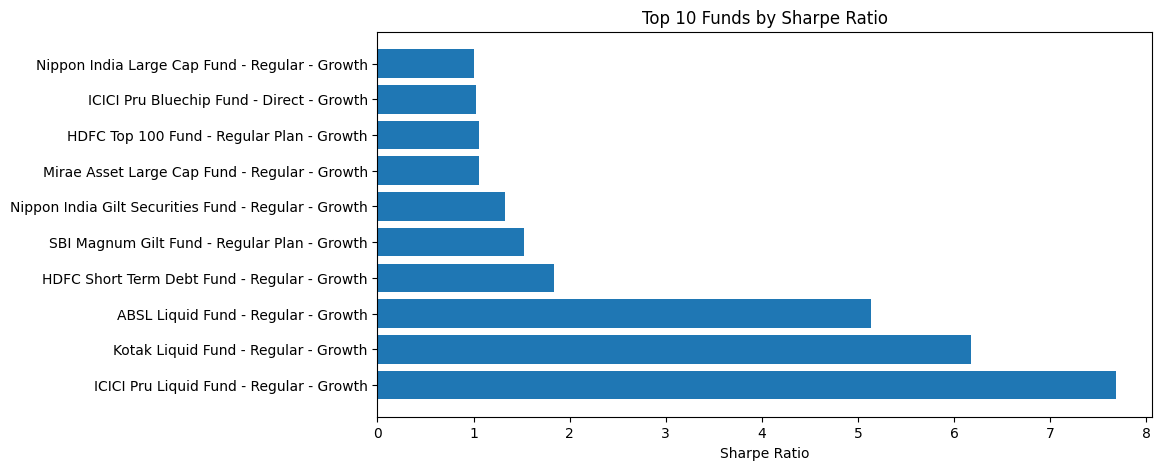

In [7]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plt.scatter(
    scheme['std_dev_ann_pct'],
    scheme['return_5yr_pct']
)

plt.xlabel("Risk (Std Dev %)")
plt.ylabel("5-Year Return %")
plt.title("Risk vs Return Analysis")

plt.show()
top_sharpe = scheme.sort_values(
    by='sharpe_ratio',
    ascending=False
)[['scheme_name','sharpe_ratio']].head(10)

top_sharpe
plt.figure(figsize=(10,5))

plt.barh(
    top_sharpe['scheme_name'],
    top_sharpe['sharpe_ratio']
)

plt.title("Top 10 Funds by Sharpe Ratio")
plt.xlabel("Sharpe Ratio")

plt.show()

In [8]:
category_return = (
    scheme.groupby('category')
    ['return_5yr_pct']
    .mean()
    .sort_values(ascending=False)
)

category_return


category
Small Cap          21.900000
Mid Cap            17.520000
Large & Mid Cap    15.680000
Flexi Cap          14.640000
ELSS               14.260000
Large Cap          13.320714
Value              12.600000
Index/ETF          12.310000
Index              11.310000
Liquid              8.050000
Gilt                7.070000
Short Duration      6.410000
Name: return_5yr_pct, dtype: float64

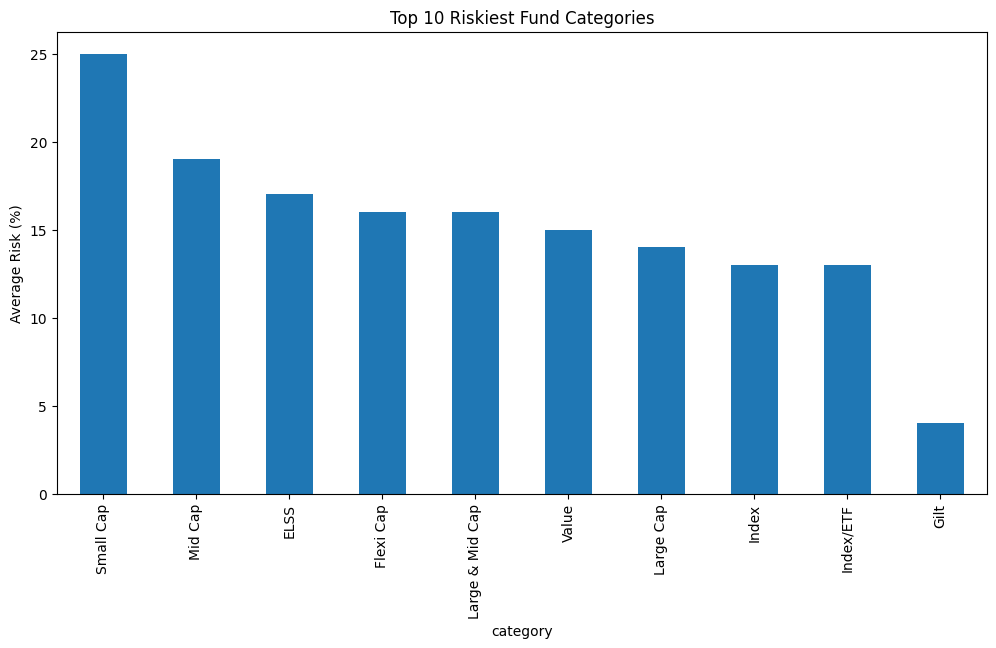

In [13]:
category_risk = (
    scheme.groupby('category')
    ['std_dev_ann_pct']
    .mean()
    .sort_values(ascending=False)
)

category_risk
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

category_risk.head(10).plot(kind='bar')

plt.title("Top 10 Riskiest Fund Categories")
plt.ylabel("Average Risk (%)")

plt.show()

In [10]:
fund_house_return = (
    scheme.groupby('fund_house')
    ['return_5yr_pct']
    .mean()
    .sort_values(ascending=False)
)

fund_house_return.head(10)

fund_house
Axis Mutual Fund            17.340000
DSP Mutual Fund             17.320000
SBI Mutual Fund             15.320000
Aditya Birla Sun Life MF    14.870000
Nippon India MF             14.464000
UTI Mutual Fund             14.316667
Mirae Asset MF              14.206667
Kotak Mahindra MF           13.232500
HDFC Mutual Fund            12.950000
ICICI Prudential MF         12.514000
Name: return_5yr_pct, dtype: float64

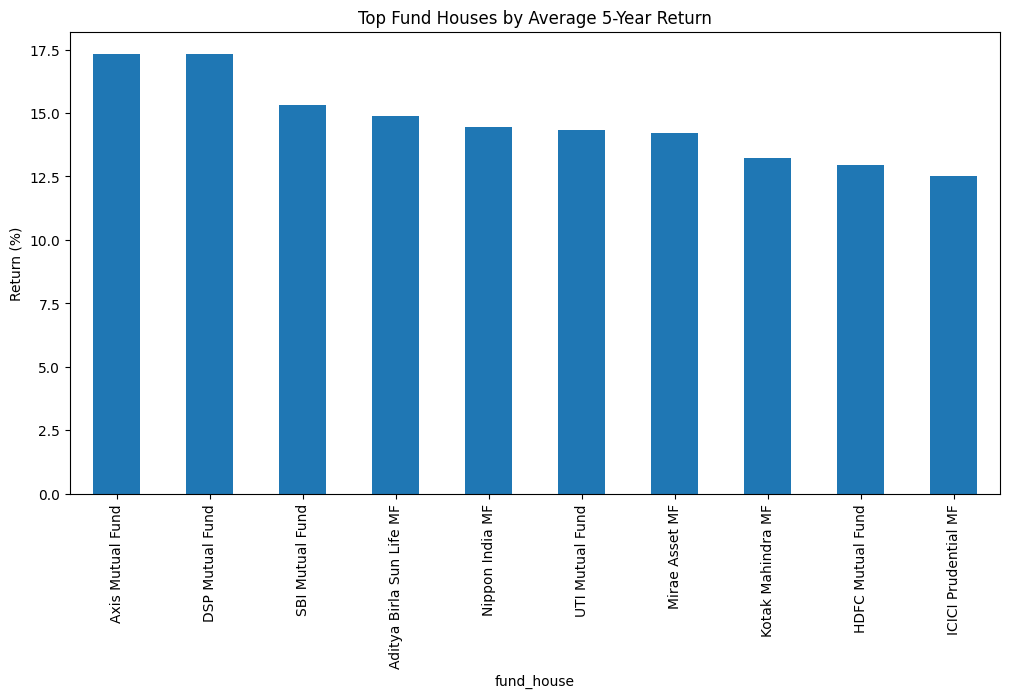

In [11]:
plt.figure(figsize=(12,6))

fund_house_return.head(10).plot(kind='bar')

plt.title("Top Fund Houses by Average 5-Year Return")
plt.ylabel("Return (%)")

plt.show()

In [14]:
aum_house = (
    scheme.groupby('fund_house')
    ['aum_crore']
    .sum()
    .sort_values(ascending=False)
)

aum_house.head(10)

fund_house
Nippon India MF             154328
Kotak Mahindra MF           145689
ICICI Prudential MF         120241
DSP Mutual Fund             114787
Aditya Birla Sun Life MF    104108
SBI Mutual Fund              94940
Axis Mutual Fund             92210
HDFC Mutual Fund             86975
UTI Mutual Fund              66990
Mirae Asset MF               63396
Name: aum_crore, dtype: int64

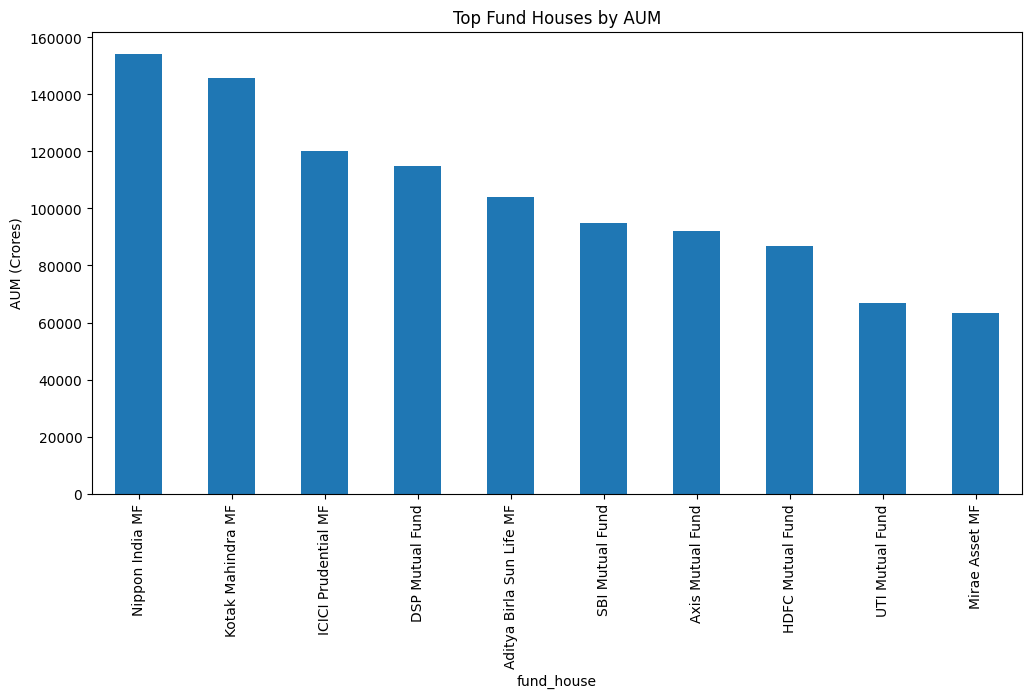

In [15]:
plt.figure(figsize=(12,6))

aum_house.head(10).plot(kind='bar')

plt.title("Top Fund Houses by AUM")
plt.ylabel("AUM (Crores)")

plt.show()

In [16]:
top_sharpe = (
    scheme[['scheme_name', 'sharpe_ratio']]
    .sort_values('sharpe_ratio', ascending=False)
)

top_sharpe.head(10)

,scheme_name,sharpe_ratio
14,ICICI Pru Liquid Fund - Regular - Growth,7.68
23,Kotak Liquid Fund - Regular - Growth,6.18
30,ABSL Liquid Fund - Regular - Growth,5.14
9,HDFC Short Term Debt Fund - Regular - Growth,1.84
4,SBI Magnum Gilt Fund - Regular Plan - Growth,1.52
19,Nippon India Gilt Securities Fund - Regular - ...,1.33
34,Mirae Asset Large Cap Fund - Regular - Growth,1.06
5,HDFC Top 100 Fund - Regular Plan - Growth,1.06
11,ICICI Pru Bluechip Fund - Direct - Growth,1.03
15,Nippon India Large Cap Fund - Regular - Growth,1.00


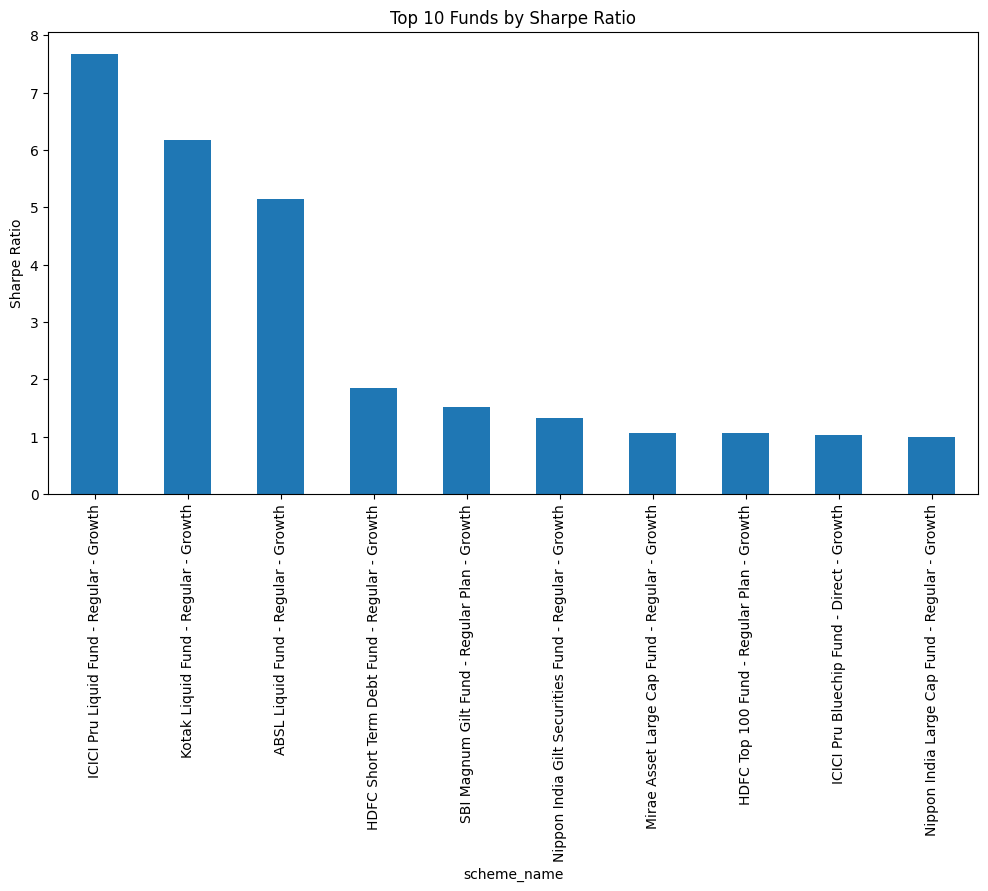

In [17]:
plt.figure(figsize=(12,6))

top_sharpe.head(10).set_index('scheme_name')['sharpe_ratio'].plot(kind='bar')

plt.title("Top 10 Funds by Sharpe Ratio")
plt.ylabel("Sharpe Ratio")

plt.show()

In [18]:
top_sortino = (
    scheme[['scheme_name', 'sortino_ratio']]
    .sort_values('sortino_ratio', ascending=False)
)

top_sortino.head(10)

,scheme_name,sortino_ratio
14,ICICI Pru Liquid Fund - Regular - Growth,10.37
23,Kotak Liquid Fund - Regular - Growth,9.70
30,ABSL Liquid Fund - Regular - Growth,8.76
9,HDFC Short Term Debt Fund - Regular - Growth,2.79
19,Nippon India Gilt Securities Fund - Regular - ...,2.38
4,SBI Magnum Gilt Fund - Regular Plan - Growth,2.11
5,HDFC Top 100 Fund - Regular Plan - Growth,1.70
15,Nippon India Large Cap Fund - Regular - Growth,1.68
3,SBI Small Cap Fund - Direct Plan - Growth,1.67
34,Mirae Asset Large Cap Fund - Regular - Growth,1.66


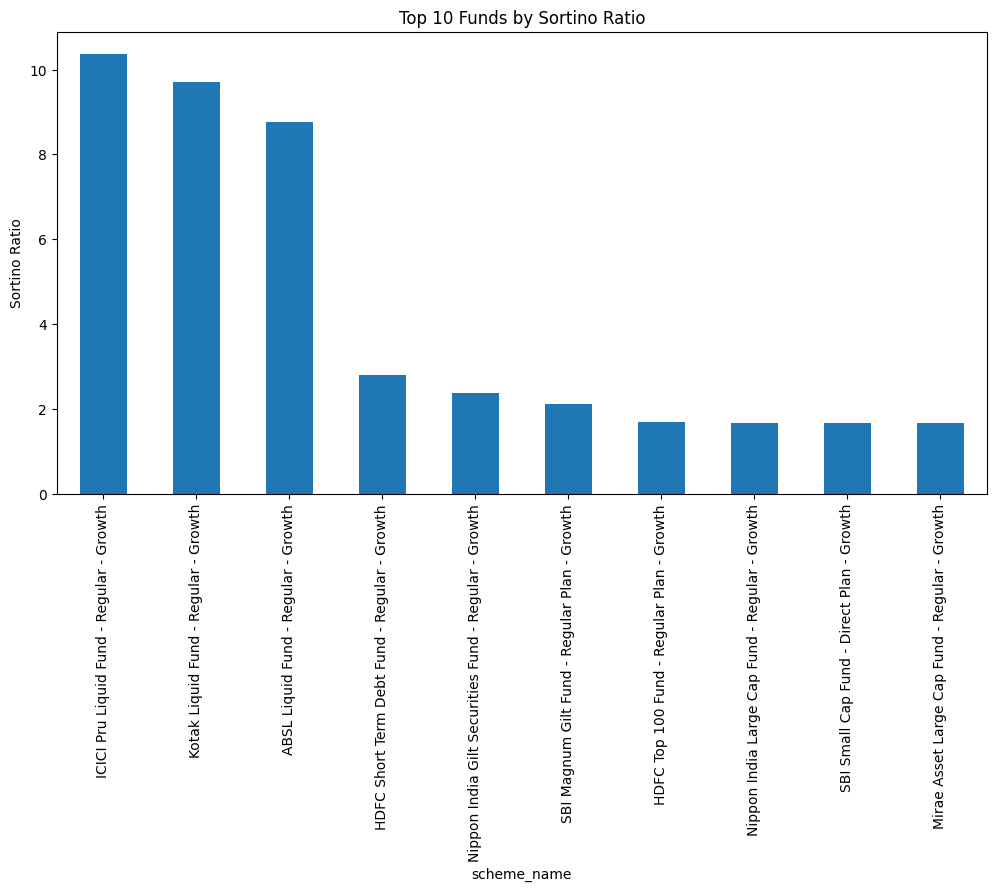

In [19]:
plt.figure(figsize=(12,6))

top_sortino.head(10).set_index('scheme_name')['sortino_ratio'].plot(kind='bar')

plt.title("Top 10 Funds by Sortino Ratio")
plt.ylabel("Sortino Ratio")

plt.show()

In [20]:
scheme[['alpha', 'beta']].describe()

,alpha,beta
count,40.000000,40.000000
mean,1.253500,0.873250
std,0.447412,0.224846
min,0.510000,0.220000
25%,0.887500,0.890000
50%,1.205000,0.960000
75%,1.700000,1.000000
max,1.980000,1.040000


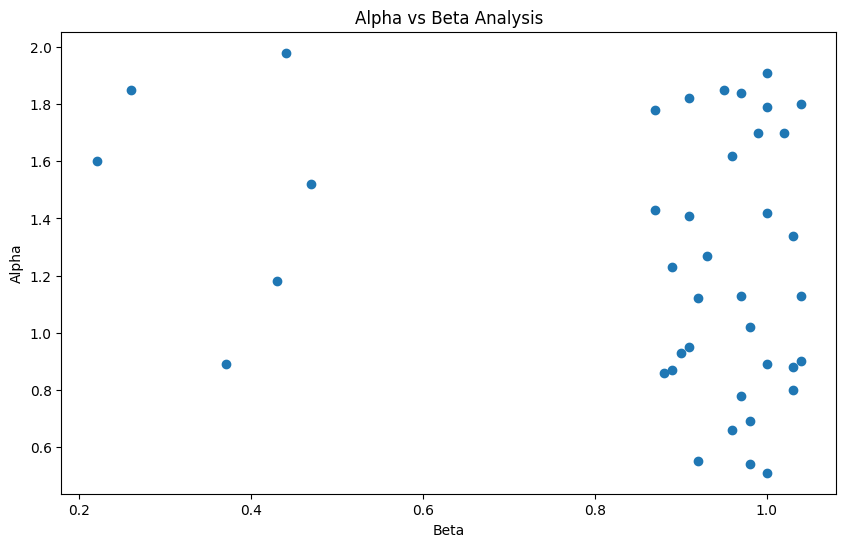

In [21]:
plt.figure(figsize=(10,6))

plt.scatter(
    scheme['beta'],
    scheme['alpha']
)

plt.xlabel("Beta")
plt.ylabel("Alpha")
plt.title("Alpha vs Beta Analysis")

plt.show()

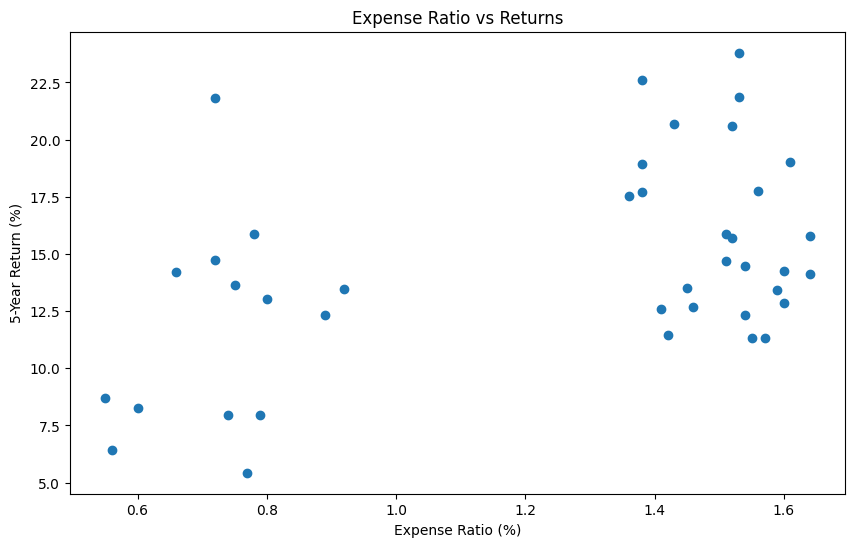

In [22]:
plt.figure(figsize=(10,6))

plt.scatter(
    scheme['expense_ratio_pct'],
    scheme['return_5yr_pct']
)

plt.xlabel("Expense Ratio (%)")
plt.ylabel("5-Year Return (%)")
plt.title("Expense Ratio vs Returns")

plt.show()

In [23]:
scheme['amfi_code'].nunique()

40

In [26]:
print([x for x in globals() if not x.startswith('_')])

['In', 'Out', 'get_ipython', 'exit', 'quit', 'open', 'pd', 'np', 'plt', 'nav', 'scheme', 'investor', 'portfolio', 'top_sharpe', 'category_return', 'category_risk', 'fund_house_return', 'aum_house', 'top_sortino', 'var']


In [27]:
for name in ['nav','scheme','investor','portfolio','aum']:
    print(name, "exists?" , name in globals())

nav exists? True
scheme exists? True
investor exists? True
portfolio exists? True
aum exists? False


In [28]:
import pandas as pd

aum = pd.read_csv("../data/processed/03_aum_by_fund_house_cleaned.csv")

In [29]:
aum['aum_crore'].sum()

np.int64(39176000)

In [ ]:
scheme['return_5yr_pct'].mean()


np.float64(14.516749999999998)

In [32]:
scheme['sharpe_ratio'].mean()

np.float64(1.3617500000000002)

In [33]:
investor['investor_id'].nunique()

5000

In [34]:
portfolio['market_value_cr'].sum()

np.float64(324848.62)

In [35]:
import os

os.makedirs("../dashboard_data", exist_ok=True)

In [37]:
top_return_funds = (
    scheme[['scheme_name', 'return_5yr_pct']]
    .sort_values('return_5yr_pct', ascending=False)
    .head(10)
)

top_return_funds.head()

,scheme_name,return_5yr_pct
29,ABSL Small Cap Fund - Regular - Growth,23.80
27,Axis Small Cap Fund - Regular - Growth,22.62
17,Nippon India Small Cap Fund - Regular - Growth,21.88
3,SBI Small Cap Fund - Direct Plan - Growth,21.82
2,SBI Small Cap Fund - Regular Plan - Growth,20.67


In [38]:
category_return = (
    scheme.groupby('category')['return_5yr_pct']
    .mean()
    .sort_values(ascending=False)
)

category_return.head()

category
Small Cap          21.90
Mid Cap            17.52
Large & Mid Cap    15.68
Flexi Cap          14.64
ELSS               14.26
Name: return_5yr_pct, dtype: float64

In [39]:
fundhouse_aum = (
    aum.groupby('fund_house')['aum_crore']
    .sum()
    .sort_values(ascending=False)
)

fundhouse_aum.head()

fund_house
SBI Mutual Fund        8491000
ICICI Prudential MF    6293000
HDFC Mutual Fund       5732000
Nippon India MF        3909000
Kotak Mahindra MF      3502000
Name: aum_crore, dtype: int64

In [40]:
sector_alloc = (
    portfolio.groupby('sector')['weight_pct']
    .sum()
    .sort_values(ascending=False)
)

sector_alloc.head()

sector
Banking       652.26
IT            455.47
Pharma        407.45
Automobile    323.65
Utilities     265.54
Name: weight_pct, dtype: float64

In [ ]:
top_return_funds.to_csv("../dashboard_data/top_return_funds.csv", index=False)

category_return.to_csv("../dashboard_data/category_return.csv")

fundhouse_aum.to_csv("../dashboard_data/fundhouse_aum.csv")

sector_alloc.to_csv("../dashboard_data/sector_alloc.csv")